In [1]:
#necessary tools for training the model
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from torch .utils.data import DataLoader, Dataset


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

print(os.listdir('/kaggle/input/datasets/ayuraj/asl-dataset/asl_dataset/'))

cuda
['n', '7', 'r', '2', 'b', 'i', 'f', 'h', '5', 'e', 'u', 'm', '8', 'x', '0', 'asl_dataset', 'k', 'q', 'y', 's', 'g', 'a', 'o', 't', 'v', 'z', '3', '1', 'c', '4', 'p', '9', 'l', '6', 'w', 'd', 'j']


In [2]:
image_paths = []
labels = []

for label in os.listdir('/kaggle/input/datasets/ayuraj/asl-dataset/asl_dataset/'):
    for image in os.listdir(f'/kaggle/input/datasets/ayuraj/asl-dataset/asl_dataset/{label}'):
        image_paths.append(f'/kaggle/input/datasets/ayuraj/asl-dataset/asl_dataset/{label}/{image}')
        labels.append(label)

data_df = pd.DataFrame(zip(image_paths, labels), columns=['image_paths', 'labels'])
data_df = data_df[data_df['labels']!='asl_dataset']

In [3]:
train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)

val = test.sample(frac=0.5)
test = test.drop(val.index)

In [4]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

base_transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ]
)

In [5]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels']))

    def __len__(self):
        
        return self.dataframe.shape[0]


    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label
        

In [6]:
train_dataset = CustomImageDataset(test, transform=base_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [7]:
#calcualte mean and standard deviation for calcuating z-score normalization

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
total_pixels = 0

for images, labels in train_loader:

    channel_sum += images.sum(dim=[0, 2, 3])
    channel_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    total_pixels += images.size(0) * images.size(2) * images.size(3)

mean = channel_sum / total_pixels
std = torch.sqrt(
    (channel_squared_sum / total_pixels) - (mean **2)
)

#TODO: MAKE SURE TO CONVERT TO CUDA WHEN TRAINING!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

print(f"Mean: {mean}")
print(f'Std: {std}')

Mean: tensor([0.2246, 0.1555, 0.1397])
Std: tensor([0.3045, 0.2226, 0.2101])


In [8]:
transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=mean.tolist(),
            std=std.tolist()
        )
    ]
)

train_dataset = CustomImageDataset(train, transform=transform)
val_dataset = CustomImageDataset(val, transform=transform)
test_dataset = CustomImageDataset(test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

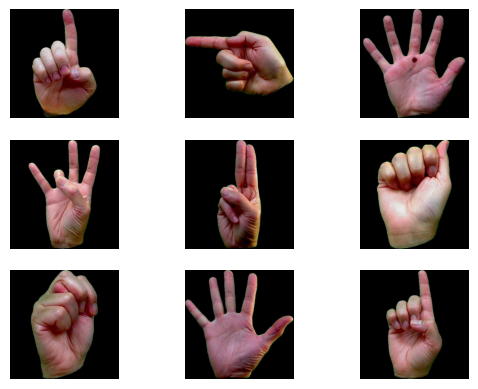

In [9]:
#visualize image

f, axs = plt.subplots(nrows=3, ncols=3)

for row in range(3):
    for col in range(3):
        image = Image.open(data_df.sample(n=1)['image_paths'].iloc[0]).convert('RGB')
        axs[row, col].imshow(image)
        axs[row, col].axis('off')
plt.show()